<a href="https://colab.research.google.com/github/jihye-kim11/2026ai/blob/master/1_LangGraph_%EC%97%90%EC%9D%B4%EC%A0%84%ED%8A%B8_%EA%B8%B0%EC%B4%88_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경 설정

In [1]:
%%capture
%pip install \
    langchain==1.2.7 \
    langchain-core==1.2.7 \
    langchain-classic==1.0.1 \
    langchain-community==0.4.1 \
    langchain-openai \
    langchain-google-genai \
    langchain_tavily \
    langgraph==1.0.7 \
    langgraph-checkpoint==4.0.0 \
    langgraph-prebuilt==1.0.7 \
    langgraph-sdk==0.3.3 \
    langsmith==0.6.6 \

%pip install gradio

import os
from IPython.display import Markdown, display

서비스를 활용하기 위해 API KEY 값이 필요합니다. 지정된 환경변수에 API KEY를 저장하면 쉽게 API를 연동할 수 있습니다.

(1) 미리 준비해둔 .env 파일을 현재 경로에 다운로드합니다.

In [2]:
!gdown 1LrdipBsfvJwmabd6vqJySgbRyOT1qPkb # 원격 드라이브에서 .env 파일 다운로드

Downloading...
From: https://drive.google.com/uc?id=1LrdipBsfvJwmabd6vqJySgbRyOT1qPkb
To: /content/.env
100% 402/402 [00:00<00:00, 1.15MB/s]


(2) load_dotenv는 .env 파일 내의 API KEY를 환경변수에 등록합니다.

In [3]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path="/content/.env", override=True)

True

(3) 환경변수에 등록이 됐는지 출력해봅시다.

In [4]:
import os

for env_var in os.environ.keys():
    if "API_KEY" in env_var:
        print(f"{env_var}:", os.environ[env_var][:10]+"*"*(len(os.environ[env_var])-10))

OPENAI_API_KEY: sk-proj-US**********************************************************************************************************************************************************
GOOGLE_API_KEY: AIzaSyC7Qc*****************************
TAVILY_API_KEY: empty
LANGSMITH_API_KEY: empty


# LangChain

LangChain은 LLM 애플리케이션 개발을 돕는 프레임워크입니다.

(1) 다양한 LLM provider(e,g OpenAI, Google, Anthropic)의 모델을 통일된 방식으로 사용할 수 있는 인터페이스 제공

(2) 타 프레임워크 보다 더 다양한 LLM 연결 기능 제공

(3) 프롬프트 엔지니어링, 출력 파서, RAG, AI 워크플로우, 에이전트 등 다양한 개발 도구 제공

## LangChain Chat LLM (Chat completion LLM) 사용하기

Chat LLM은 메시지 리스트를 입력 받아 응답을 생성하는 대화형 LLM입니다. 챗봇, 대화형 워크플로우, 대화형 RAG, 에이전트 개발 등에 적용되는 가장 보편적인 모델입니다. 데이터를 처리하려면 invoke 메서드에 메시지 목록을 전달하면 됩니다.

LangChain [Chat llm](https://python.langchain.com/docs/integrations/chat/) 객체는 다음과 같이 생성합니다.

In [5]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5-mini", model_provider="openai", temperature=0.6)

- model : 사용할 llm 모델 명칭
- model_provider : `openai`, `anthropic`, `google_genai` 등. pip install로 [제품사 패키지 추가설치 필요](https://python.langchain.com/docs/integrations/chat/#featured-providers).
    - 예를 들어 openai의 경우 langchain-openai 설치
- temperature : 낮을 수록 일관되고 높을 수록 무작위적이고 창의적이 됩니다.

.invoke 메서드로 LLM에 프롬프트 텍스트를 전달합니다. 결과는 AIMessage 타입의 데이터입니다.

In [6]:
ai_response = llm.invoke("안녕하세요? 당신은 어떤 모델인가요?")

(1) Response 내용 : 응답 텍스트는 content 속성에 있습니다.

In [7]:
ai_response.content

'안녕하세요! 저는 OpenAI가 만든 대형 언어 모델 ChatGPT입니다. (기본적으로 GPT‑4 계열 아키텍처에 기반하며, 지식은 2024년 6월까지입니다.)\n\n간단한 설명:\n- 할 수 있는 일: 질문에 답하기, 글쓰기·요약·번역·교정, 코드 작성·디버깅, 아이디어 브레인스토밍, 문제 풀이, 학습 보조 등 다양한 텍스트 기반 작업을 도와드릴 수 있어요.\n- 제한 사항: 실시간 인터넷 검색이나 최신 사건 확인은 할 수 없고(지식 컷오프 이후 정보 불확실), 때로는 틀리거나 모호한 답을 할 수 있습니다. 개인의 기밀 정보나 외부 계정에 접근할 수 없고, 의학·법률·재무 같은 전문 분야 조언은 전문가 확인이 필요합니다.\n- 개인정보: 대화 중 사용자가 제공한 정보만 이용합니다. 비밀번호 등 민감한 정보는 공유하지 마세요.\n\n원하시면 지금 바로 도와드릴게요 — 무엇을 도와드릴까요?'

(2) 응답 관련 메타데이터도 확인할 수 있습니다.

llm provider의 api platform에서 지원 모델과 토큰 당 가격을 확인 가능 : [openai](https://platform.openai.com/docs/pricing)

In [8]:
ai_response.response_metadata

{'token_usage': {'completion_tokens': 639,
  'prompt_tokens': 16,
  'total_tokens': 655,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 384,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-5-mini-2025-08-07',
 'system_fingerprint': None,
 'id': 'chatcmpl-DcgcNkaLhBK290tCDve4HldlnupVj',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

(3) langchain llm의 response 데이터 타입은 Message의 한 종류인 `AIMessage` 입니다.

In [9]:
type(ai_response)

langchain_core.messages.ai.AIMessage

In [10]:
ai_response

AIMessage(content='안녕하세요! 저는 OpenAI가 만든 대형 언어 모델 ChatGPT입니다. (기본적으로 GPT‑4 계열 아키텍처에 기반하며, 지식은 2024년 6월까지입니다.)\n\n간단한 설명:\n- 할 수 있는 일: 질문에 답하기, 글쓰기·요약·번역·교정, 코드 작성·디버깅, 아이디어 브레인스토밍, 문제 풀이, 학습 보조 등 다양한 텍스트 기반 작업을 도와드릴 수 있어요.\n- 제한 사항: 실시간 인터넷 검색이나 최신 사건 확인은 할 수 없고(지식 컷오프 이후 정보 불확실), 때로는 틀리거나 모호한 답을 할 수 있습니다. 개인의 기밀 정보나 외부 계정에 접근할 수 없고, 의학·법률·재무 같은 전문 분야 조언은 전문가 확인이 필요합니다.\n- 개인정보: 대화 중 사용자가 제공한 정보만 이용합니다. 비밀번호 등 민감한 정보는 공유하지 마세요.\n\n원하시면 지금 바로 도와드릴게요 — 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 639, 'prompt_tokens': 16, 'total_tokens': 655, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DcgcNkaLhBK290tCDve4HldlnupVj', 'service_tier': 'default', 'finish_reason

### LLM과 메시지 리스트

우리가 사용하는 ChatLLM은 대화형 데이터를 처리하기 위해 SystemMessage, HumanMessage, AIMessage, ToolMessage 객체를 사용하여 [메시지](https://python.langchain.com/docs/concepts/messages/)를 정의합니다.

In [11]:
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

messages = [
    SystemMessage("당신은 오직 한국어로 답변하는 친절한 AI입니다. 간결하게 답변합니다."),
    HumanMessage("제 이름은 제이든입니다. 취미는 독서입니다."),
    AIMessage("안녕하세요! 제이든. 좋은 취미입니다."),
    HumanMessage("제 취미를 더 잘 즐길 수 있는 방법을 알려주세요.")
]

llm.invoke(messages)

AIMessage(content='좋아요, 제이든 — 독서를 더 즐기기 위한 간단한 방법들:\n\n- 매일 고정 시간 정하기(예: 잠들기 전 20분).  \n- 편한 독서 공간 만들기(조명·의자·음료 준비).  \n- 한 번에 작은 목표 설정(한 챕터 또는 30쪽).  \n- 장르를 섞어 읽기(소설·논픽션·시 등 번갈아).  \n- 오디오북과 전자책도 활용해 이동 시간 활용.  \n- 독서 노트 쓰기(인상 깊은 문장·짧은 감상).  \n- 북클럽·독서모임 참여로 토론하고 동기부여 얻기.  \n- 읽을 목록(TBR) 관리하고 새 책은 한두 권씩만.  \n- 휴대용 책 또는 앱으로 언제든 읽기 가능하게.  \n- 속독보다 이해 우선, 요약해보면 흡수력 향상.  \n- 독서 챌린지나 목표로 재미 요소 추가(월별 테마).  \n- SNS나 친구와 감상 공유해 더 깊게 즐기기.\n\n원하면 좋아하는 장르나 최근 읽은 책 알려줘. 맞춤 추천과 읽기 계획 제안해줄게.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 738, 'prompt_tokens': 86, 'total_tokens': 824, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dch6yHkb8DThFbghqUS4yka0ZfoQo', 'service_tier': 'defau

# LangGraph


LangGraph는 워크플로우를 모델링하기 위한 프레임워크입니다. LangChain의 컴포넌트를 바탕으로 **복잡한 워크플로우, 에이전트 구조를 그래프 형태로 모델링** 가능합니다.

### (1) LangGraph Chatbot

유저와 다중회차(Multi-turn) 대화를 위한 LangGraph 챗봇을 구축해보겠습니다.

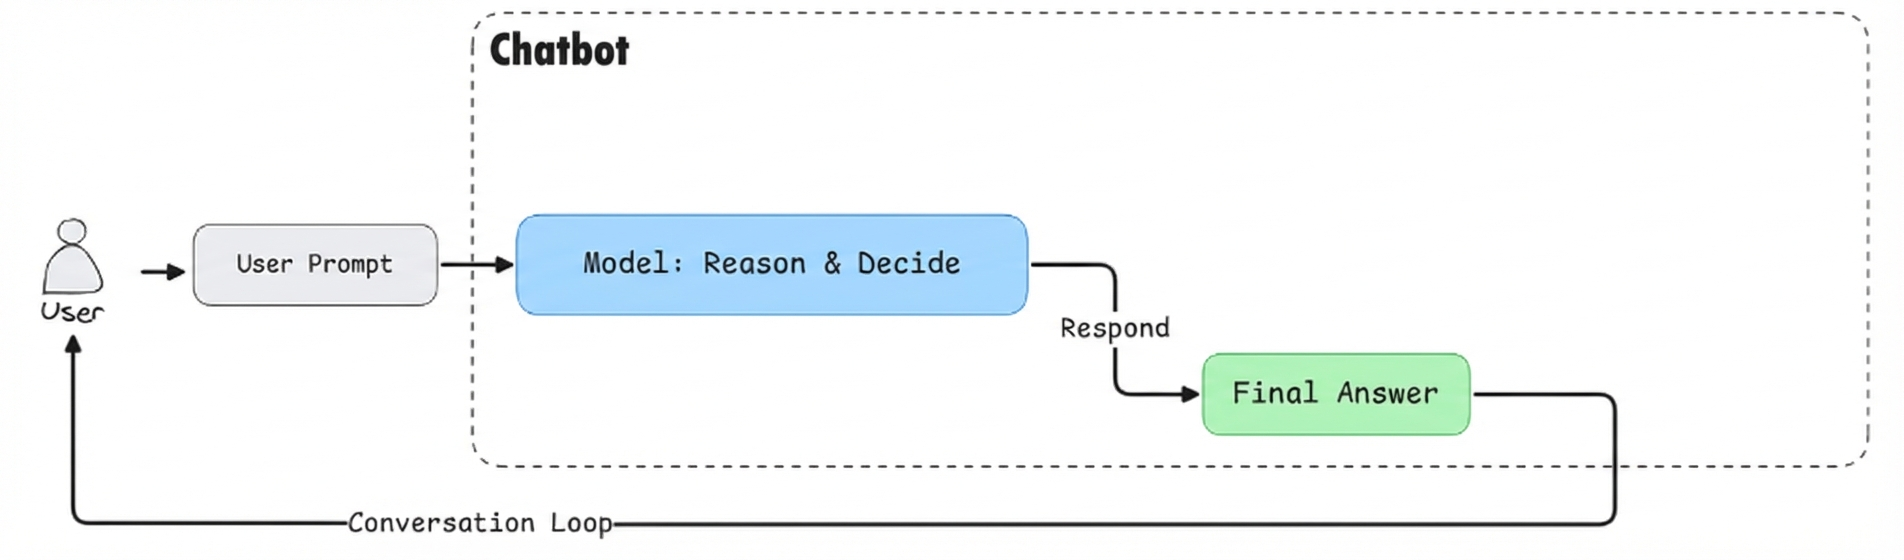

#### 챗봇 구축

Chatbot에서는 state에서 대화 이력(Chat history)를 다뤄야 합니다. LangGraph에서는 상태 정보에 대화 이력을 효율적으로 쌓기 위한 기능을 제공합니다. 아래에서 messages 항목을 정의하는 방식을 자세히 살펴봅니다.

In [39]:
from langchain_core.messages import AnyMessage, AIMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

# OpenAI의 ChatOpenAI 모델을 사용하여 LLM 초기화
llm = init_chat_model(model="gpt-5-mini", model_provider="openai", temperature=0.6)

# 아래와 같이 messages 항목을 사전 빌드된 함수인 add_messages로 annotated하면, 목록이 업데이트될 때 덮어쓰지 않고 새롭게 추가됩니다.
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [40]:
def chatbot(state: State):
    return {"messages" : llm.invoke(state["messages"])} #기존의 message 리스트에 llm의 응답 메시지가 추가(add_messages)

In [41]:
from langgraph.graph import StateGraph, START, END

# initiate a graph
chatbot_graph = StateGraph(State)

# add a node
chatbot_graph.add_node("chatbot", chatbot)

# connect nodes
chatbot_graph.add_edge(START, "chatbot")
chatbot_graph.add_edge("chatbot", END)

# compile the graph
chatbot = chatbot_graph.compile()

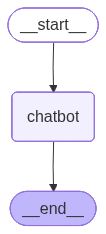

In [42]:
from IPython.display import Image, display

display(Image(chatbot.get_graph().draw_mermaid_png()))

In [43]:
from langchain_core.messages import HumanMessage

result = chatbot.invoke({"messages": [HumanMessage("안녕")]})

결과 보기

In [44]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

안녕
================================== Ai Message ==================================

안녕하세요! 만나서 반가워요. 무엇을 도와드릴까요?


`result`는 chatbot_graph의 종료 상태입니다.

대화 맥락 유지를 위해 `기존 대화 + 유저 프롬프트`로 대화를 이어나갑니다.

In [45]:
result = chatbot.invoke({"messages" : result["messages"]
                                       + [HumanMessage("LLM에서 메시지 리스트가 뭔지 설명해줘.")]})

In [46]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

안녕
================================== Ai Message ==================================

안녕하세요! 만나서 반가워요. 무엇을 도와드릴까요?
================================ Human Message =================================

LLM에서 메시지 리스트가 뭔지 설명해줘.
================================== Ai Message ==================================

좋아요 — LLM(대형 언어 모델)에서 말하는 "메시지 리스트(message list)"가 무엇인지 한국어로 간단하고 핵심만 정리해 드릴게요.

요약
- 메시지 리스트는 모델에 전달하는 대화 내역(문맥)을 순서대로 나열한 배열입니다.
- 각 항목(메시지)은 보통 역할(role)과 내용(content)으로 구성되어, 모델이 누가 무슨 말을 했는지 이해하도록 돕습니다.

구성 요소
- role: 보통 "system", "user", "assistant" 등이 사용됩니다.
  - system: 전체 대화의 동작 지침(예: 응답 스타일, 제약)을 담는 역할. 일반적으로 리스트 맨 앞(우선권 높음).
  - user: 사용자 입력(질문, 명령).
  - assistant: 모델의 이전 응답(대화 히스토리 유지).
  - 일부 구현에는 name 필드나 function 관련 항목이 추가될 수 있음.
- content: 실제 텍스트(질문, 답변, 지시문 등).
- (선택적) 메타데이터: 타임스탬프, 메시지 id, 토큰 수 등.

예시 (JSON 형태)
[
  { "role": "system", "content": "당신은 친절한 여행 안내봇입니다." },
  { "role": "user",   "co

위 방식은 비효율적입니다. 그래프에 `단기 메모리`를 추가할 수 있습니다. 단기 메모리는 그래프의 상태(State)를 유지합니다.

원래 LangGraph는 그래프가 종료되면 state를 초기화합니다. Chatbot은 유저와 AI의 대화 1턴 후 그래프가 종료되므로 대화 맥락이 유지되지 않습니다. 따라서 Chatbot의 상태(messages)를 지속적으로 누적하도록 단기 메모리를 결합합니다.

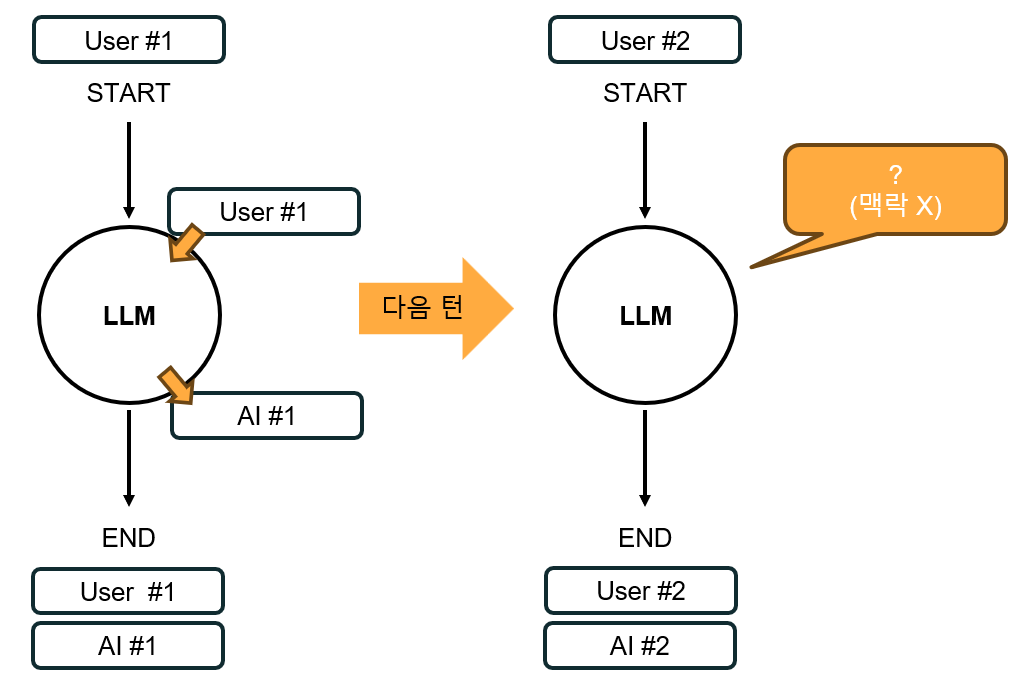



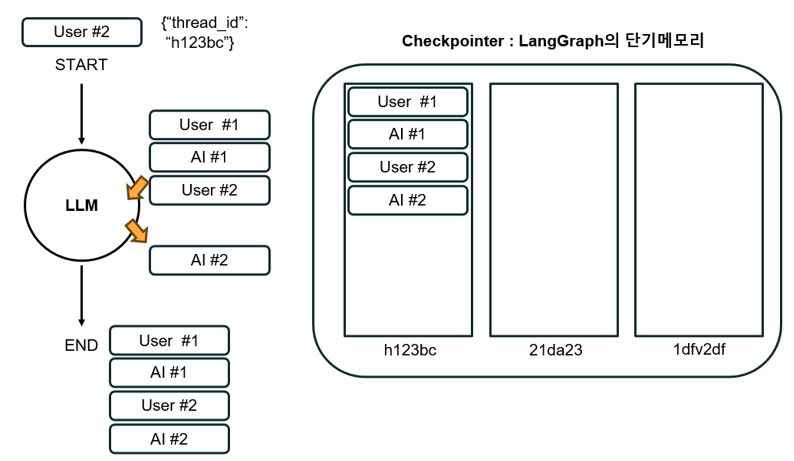

In [47]:
from langgraph.checkpoint.memory import MemorySaver

memory_chatbot = chatbot_graph.compile(checkpointer=MemorySaver()) # 그래프의 단기메모리인 체크포인터를 설정합니다.

In [48]:
config = {"configurable": {"thread_id": "user_123"}}
memory_chatbot.invoke({"messages": [HumanMessage("안녕")]}, config=config)

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='886ec907-9fc3-4afd-9e11-03b71cb5e4f1'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 8, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DcigB6n0bLg18IUqXfht3X0XprxP6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e003e-e88c-7af1-b95c-32562c89a883-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 84, 'total_tokens': 92, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [49]:
config = {"configurable": {"thread_id": "user_123"}}
memory_chatbot.invoke({"messages": [HumanMessage("에이전트의 단기 메모리가 뭔지 설명해줘.")]}, config=config)

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='886ec907-9fc3-4afd-9e11-03b71cb5e4f1'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 8, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DcigB6n0bLg18IUqXfht3X0XprxP6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e003e-e88c-7af1-b95c-32562c89a883-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 84, 'total_tokens': 92, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [51]:
config = {"configurable": {"thread_id": "user_125"}}
memory_chatbot.invoke({"messages": [HumanMessage("방금 우리가 무슨 대화를 했지?")]}, config=config)

{'messages': [HumanMessage(content='방금 우리가 무슨 대화를 했지?', additional_kwargs={}, response_metadata={}, id='40427690-df13-44ce-9442-144a59a23c01'),
  AIMessage(content='이번 세션에서는 방금 하신 질문 한 건뿐이에요 — 다른 대화를 나눈 적은 없습니다. 이전 세션의 대화는 제가 볼 수 없어요.\n\n원하시면 지금부터 대화를 이어가거나 다루고 싶은 주제를 알려주시면 요약·정리해 드릴게요. 어떤 걸 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 404, 'prompt_tokens': 16, 'total_tokens': 420, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dcih61u9j1c1UZ62ARmKER9JGp2jV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e003f-c7b6-7233-a9d1-88ce87a4b7f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_

그래프의 `get_state`를 통해 체크포인터에 저장된 `상태`를 확인합니다.

In [52]:
state = memory_chatbot.get_state(config)

In [53]:
for message in state.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

방금 우리가 무슨 대화를 했지?
================================== Ai Message ==================================

이번 세션에서는 방금 하신 질문 한 건뿐이에요 — 다른 대화를 나눈 적은 없습니다. 이전 세션의 대화는 제가 볼 수 없어요.

원하시면 지금부터 대화를 이어가거나 다루고 싶은 주제를 알려주시면 요약·정리해 드릴게요. 어떤 걸 도와드릴까요?


#### Gradio의 챗인터페이스를 사용한 대화

Gradio는
- **UI를 구성하는 요소를 정의하는 부분**
- **요소의 이벤트(버튼 누름, 텍스트 입력 등)를 처리하는 부분**

으로 구성합니다.

In [55]:
    # LangGraph 실행 설정 (thread_id로 대화 관리)
    config = {"configurable": {"thread_id": "conversation_1"}}

    def user_func(user_message, history: list):
        return "", history + [{"role": "user", "content": user_message}]

    def bot_func(history: list):
        result = memory_chatbot.invoke({"messages": [HumanMessage(history[-1]["content"])]}, config=config)

        try:
            assistant_text = result["messages"][-1].content
        except Exception:
            assistant_text = str(result)

        history.append({"role": "assistant", "content": assistant_text})
        return history

In [56]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import gradio as gr

with gr.Blocks(title="Custom Chatbot (gr.Chatbot)") as demo:

    # UI를 구성하는 요소를 정의하는 부분
    gr.Markdown("### LangGraph 커스텀 챗봇")

    chatbot = gr.Chatbot(
        label="AI Agent",
        height=500,
        type="messages",  # (선택) 새 메시지 포맷과 호환
        show_copy_button=True
    )
    user_input = gr.Textbox(
        placeholder="메시지를 입력하세요...",
        label="입력",
        autofocus=True
    )
    clear_btn = gr.ClearButton([chatbot, user_input])


    # 요소의 이벤트(버튼 누름, 텍스트 입력 등)를 처리하는 부분
    # 제출 흐름: (1) 사용자 메시지 추가 -> (2) 봇 응답 생성

    submit_event = user_input.submit(
        user_func,
        inputs=[user_input, chatbot],
        outputs=[user_input, chatbot],
        queue=False
    ).then(
        bot_func,      # LangGraph 호출 후 마지막 턴의 봇 응답 채우기
        inputs=[chatbot],
        outputs=[chatbot]
    )

    # 버튼 클릭으로도 동일 동작 지원
    send_btn = gr.Button("전송")
    send_btn.click(
        user_func,
        inputs=[user_input, chatbot],
        outputs=[user_input, chatbot],
        queue=False
    ).then(
        bot_func,
        inputs=[chatbot],
        outputs=[chatbot]
    )

if __name__ == "__main__":
    demo.launch()

/tmp/ipykernel_6607/633137491.py:10: DeprecationWarning: The 'show_copy_button' parameter will be removed in Gradio 6.0. You will need to use 'buttons=["copy"]' instead.
  chatbot = gr.Chatbot(
/tmp/ipykernel_6607/633137491.py:10: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b03acec3962a6a6727.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### (2) LangGraph 에이전트

LangGraph **Agent**는 주어진 작업을 수행하기 위해 연동된 외부 도구를 호출하여 문제를 해결합니다.

LLM(언어 모델)을 기반으로 하며, 그래프 내에서 **도구(Tool or Functions)**와 상호작용하여 LLM에게 어려운 작업을 처리할 수 있습니다. LLM은 자연어 처리 능력만으로 제한적일 수 있으므로, 특정 작업(예: 데이터 검색, 계산, 파일 읽기 등)을 수행하기 위해 외부의 도구를 호출합니다.

LangChain은 다양한 도구(Tool)와 툴킷(Toolkit)을 통해 LLM 에이전트의 기능을 확장할 수 있도록 지원합니다. 이러한 도구들은 LLM이 외부 시스템과 쉽게 상호작용할 수 있게 하여, 단순한 텍스트 응답을 넘어 실제 행동을 수행할 수 있도록 합니다. [클릭하여 관련 페이지 접속](https://python.langchain.com/docs/integrations/tools/#all-tools)

---

| 카테고리 (Category) | 주요 기능 | 포함된 도구 및 툴킷 |
| :--- | :--- | :--- |
| 🔍 **검색 (Search)** | LLM이 실시간 웹 검색을 수행하도록 지원 | `Bing Search`, `Google Search`, `DuckDuckGo Search`, `Tavily Search`, `SerpAPI` |
| 🧮 **코드 실행 (Code Execution)** | 코드 실행 환경을 통해 계산, 데이터 분석 등 수행 | `Python REPL`, `Bearly Code Interpreter`, `Riza Code Interpreter` |
| 📁 **파일 관리 (File Management)** | 파일 시스템과 상호작용하여 파일 읽기, 쓰기, 삭제 등 수행 | `FileManagementToolkit`, `ReadFileTool`, `WriteFileTool`, `DeleteFileTool`, `ListDirectoryTool` |
| 🗄️ **데이터베이스 (Database)** | 다양한 데이터베이스와 연동하여 데이터 조회 및 조작 | `SQLDatabase Toolkit`, `MongoDB`, `Redis`, `Cassandra Database Toolkit` |
| 📧 **생산성 (Productivity)** | 이메일, 캘린더, 협업 도구 등과 연동하여 업무 자동화 | `Gmail Toolkit`, `Office365 Toolkit`, `Slack Toolkit`, `Jira Toolkit` |
| 🌐 **웹 브라우징 (Web Browse)** | 웹 페이지의 탐색 및 상호작용 자동화 | `Playwright Browser Toolkit`, `Hyperbrowser`, `MultiOn Toolkit` |
| 💰 **금융 (Finance)** | 금융 데이터 조회 및 거래 실행 지원 | `GOAT`, `Google Finance`, `Yahoo Finance News` |

---

#### Tool creation

(1) tavily api 사용

Tavily는 LLM과 web 검색을 연동하기 위한 API입니다. API를 사용하기 위해 Key값을 받아와야 합니다.

[Tavily.com](https://app.tavily.com/)에 접속해 가입하고, API key를 생성합시다.

그림. tavily.com의 대시보드(아래 Key를 클릭하면 값을 복사할 수 있다)

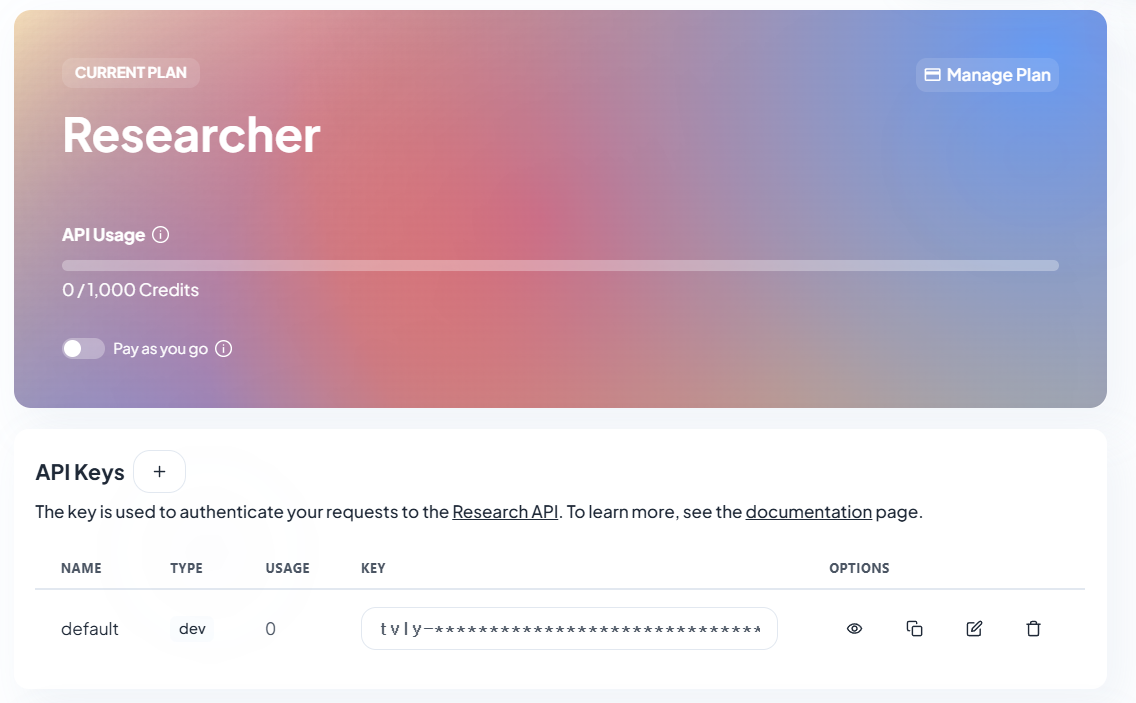

**새로운 API Key는 .env에 기입하고, load_dotenv 함수를 재실행합니다.**


In [59]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path="/content/env", override=True)

True

[1.Tavily Search](https://docs.tavily.com/documentation/integrations/langchain#tavily-search)

검색 쿼리를 받아 웹에서 관련 문서/페이지를 찾아주는 도구입니다.

In [60]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(max_results=5, topic="general") #검색 쿼리를 받아 웹에서 관련 문서/페이지를 찾아주는 도구입니다.

tavily_search.invoke("2025 버팀목 대출 소득 기준")

{'query': '2025 버팀목 대출 소득 기준',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://blog.naver.com/kakaoiu/224132910502',
   'title': '버팀목 전세자금대출 조건, 한도, 소득 기준 총정리 (2025년 최신판)',
   'content': '일반 가구: 연 소득 5천만 원 이하 · 신혼 가구: 연 소득 7천 5백만 원 이하 (혼인 7년 이내) · 신생아 가구: 연 소득 1억 3천만 원 이하 (2년 내 출산).',
   'score': 0.8657814,
   'raw_content': None},
  {'url': 'https://blog.naver.com/habit-maker/224009530888',
   'title': '2025년 청년 버팀목 전세자금대출 A to Z (조건, 금리, 한도, 서류 총정리)',
   'content': '소득: 부부합산 연소득 5천만원 이하 (단, 신혼부부/2자녀 이상 가구 등은 소득 기준 완화). 자산: 2025년 기준 순자산 가액이 3.45억원 이하. 기타',
   'score': 0.8473754,
   'raw_content': None},
  {'url': 'https://groupby.careers/2025%EB%85%84-%EC%A0%84%EC%84%B8%EB%8C%80%EC%B6%9C-%EC%B2%AD%EB%85%84%EB%B2%84%ED%8C%80%EB%AA%A9%EC%A0%84%EC%84%B8%EB%8C%80%EC%B6%9C-%EC%99%84%EB%B2%BD-%EA%B0%80%EC%9D%B4%EB%93%9C/',
   'title': '2025년 전세대출 청년버팀목전세대출 완벽 가이드 - 그룹바이 블로그',
   'content': '대상, 만 19~34세 무주택 청년 (병역 이행 시 만 39세까지 가능0 ; 소득 요건, 연소득 5천만

[2.Tavily extract](https://docs.tavily.com/documentation/integrations/langchain#tavily-extract)

특정 URL 목록에서 실제 콘텐츠(텍스트, 이미지)를 추출하는 도구입니다.



In [61]:
from langchain_tavily import TavilyExtract

tavily_extract = TavilyExtract(extract_depth="advanced", include_images=False)

result = tavily_extract.invoke({
    "urls": ["https://kbthink.com/main/asset-management/wealth-manage-tip/kbthink-original/202410/beotimok-newlyweds.html"]
})

In [63]:
result

{'results': [{'url': 'https://kbthink.com/main/asset-management/wealth-manage-tip/kbthink-original/202410/beotimok-newlyweds.html',
   'title': '신혼가구 전용 버팀목 전세자금대출에 대한 모든 것',
   'raw_content': '# 신혼가구 전용 버팀목 전세자금대출에 대한 모든 것\n\n뒤로 닫기\n\n[홈버튼](https://kbthink.com/main.html)\n\n[통합검색](https://kbthink.com/search.html)전체메뉴\n\n[홈](https://kbthink.com/main.html)[대출 종류 총정리](https://kbthink.com/loan-guide.html)\n\n# 신혼가구 전용 버팀목 전세자금대출에 대한 모든 것\n\n 신혼부부를 위한 신혼가구 버팀목 전세자금대출 \n\n 25.09.30. \n\n 읽는시간 5 분 \n\n0\n\n좋아요\n\n가\n\n가 Aa\n작게\n\n가 Aa\n보통\n\n가 Aa\n크게\n\n공유\n\n메뉴 닫기\n대출\n\n*   [대출 종류](https://kbthink.com/loan-guide.html)\n*    대출 기본 이해 \n    *   [LTV·DSR·DTI](https://kbthink.com/loan-guide/ltv-dti-dsr.html)\n    *   [스트레스 DSR 3단계](https://kbthink.com/loan-guide/stressdsr.html)\n    *   [마이너스 통장 vs 신용대출](https://kbthink.com/loan-guide/minus-account.html)\n\n*    금리·이자 이해 \n    *   [대출 우대금리 조건](https://kbthink.com/loan-guide/interest-rate.html)\n    *   [고정금리 vs 변동금리](https://kbthink.com/loan-g

[3.Tavily Web Crawl](https://docs.tavily.com/documentation/integrations/langchain#tavily-crawl)

TavilyCrawl은 단일 웹페이지가 아니라, 지정된 도메인이나 여러 URL을 재귀적으로 탐색(crawl) 하여 관련된 페이지의 본문을 한 번에 수집하는 LangChain 통합 도구입니다.
단순히 검색(tavily_search)하거나 단일 URL의 본문을 추출(tavily_extract)하는 것보다 넓은 범위의 웹 콘텐츠를 체계적으로 수집할 때 사용합니다.

In [75]:
from langchain_tavily import TavilyCrawl

tavily_crawl = TavilyCrawl(max_depth=2, max_pages=10)

result = tavily_crawl.invoke({
    "url": "https://news.naver.com/"
})

In [76]:
result

{'base_url': 'https://news.naver.com/',
 'results': [{'url': 'https://news.naver.com/',
   'raw_content': '[본문 바로가기](#ct)\n\n[NAVER](https://www.naver.com)\n\n# [뉴스](https://news.naver.com)\n\n  [엔터](https://entertain.naver.com/home)     [스포츠](https://sports.news.naver.com/index)     [날씨](https://weather.naver.com/)     [프리미엄](https://contents.premium.naver.com/)\n\n[MY](https://media.naver.com/my/home) \n\n뉴스 이용 설정을 할 수 있어요\n\n* [언론사별](https://news.naver.com/?viewType=pc)\n* [정치](https://news.naver.com/section/100)\n* [경제](https://news.naver.com/section/101)\n* [사회](https://news.naver.com/section/102)\n* [생활/문화](https://news.naver.com/section/103)\n* [IT/과학](https://news.naver.com/section/105)\n* [세계](https://news.naver.com/section/104)\n* [랭킹](https://news.naver.com/main/ranking/popularDay.naver)\n* [신문보기](https://news.naver.com/newspaper/home?viewType=pc)\n* [오피니언](https://news.naver.com/opinion/home)\n* [TV](https://news.naver.com/main/tv/index.naver?mid=tvh)\n* [팩트체크](https://news

(2) FileManagementToolkit 사용

LangChain의 `FileManagementToolkit`은 로컬 파일 시스템과 상호 작용하는 데 사용되는 도구 모음입니다. `root_dir="./sandbox"`로 초기화하면 모든 파일 작업 (읽기, 쓰기, 삭제 등)이 현재 작업 디렉토리 아래의 `sandbox`라는 폴더 내에서만 수행되도록 제한됩니다. 이는 보안상 중요한 기능으로, AI 에이전트가 지정된 디렉토리 외부의 파일에 접근하거나 수정하는 것을 방지합니다.

`FileManagementToolkit`에서 제공하는 주요 함수(도구)는 다음과 같습니다.

| 함수 (Tool Name) | 설명 |
| :--- | :--- |
| `copy_file` | 파일을 복사합니다. |
| `file_delete` | 파일을 삭제합니다. |
| `file_search` | 디렉토리 내에서 파일을 검색합니다. |
| `move_file` | 파일을 다른 위치로 이동하거나 이름을 변경합니다. |
| `read_file` | 파일의 내용을 읽습니다. |
| `write_file` | 파일에 내용을 씁니다. (기존 파일은 덮어쓸 수 있습니다) |
| `list_directory` | 지정된 디렉토리의 파일 및 폴더 목록을 보여줍니다. |

**`root_dir="./sandbox"`의 의미**

* **작업 영역 제한**: 모든 도구의 파일 경로는 `./sandbox`를 기준으로 해석됩니다. 예를 들어, `write_file` 도구에 `my_file.txt`라는 경로를 전달하면, 실제로는 `./sandbox/my_file.txt`에 파일이 생성됩니다.
* **보안**: 이 설정을 통해 에이전트가 시스템의 다른 중요한 파일에 접근하는 것을 막을 수 있습니다. 샌드박스 환경 내에서만 파일 작업을 허용하므로 안전하게 파일 관리 기능을 사용할 수 있습니다.

In [66]:
# FileManagementToolkit을 가져옵니다. 이 도구는 파일 관리 작업을 수행하는 데 사용됩니다.
from langchain_community.agent_toolkits import FileManagementToolkit

# 루트 디렉토리 설정
file_management_tools = FileManagementToolkit(root_dir="./sandbox").get_tools()

#### Tool binding

llm의 bind_tools 기능을 통해 tools들을 연결할 수 있습니다.

In [67]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5-mini", model_provider="openai", temperature=0.6)

tools = [tavily_search, tavily_extract] + file_management_tools
llm_with_tools = llm.bind_tools(tools)

#### Tool calling Agent 구축

In [68]:
from langchain_core.messages import AnyMessage, AIMessage, SystemMessage, HumanMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition  # 도구 호출 조건을 확인하는 조건부 로직
from langgraph.prebuilt import ToolNode  # 도구 노드를 정의하는 미리 빌드된 클래스
from langgraph.graph.message import add_messages
from datetime import date

# 오늘 날짜를 YYYY-MM-DD 형식으로 가져옵니다.
today_date = date.today().strftime("%Y-%m-%d")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    system_message = SystemMessage(f"""당신은 친절하게 답변하는 대화형 에이전트입니다.
                                       유저의 요청을 처리하기 위해 필요 시 Tool을 호출해 사용할 수 있습니다.
                                       유저가 시점을 밝히지 않았다면 현재 시점 기준으로 검색하세요.
                                       오늘의 날짜 : {today_date} """)

    return {"messages" : llm_with_tools.invoke([system_message]+state["messages"])}

# initiate a graph
agent_builder = StateGraph(State)

# add a node
agent_builder.add_node("chatbot", chatbot)
agent_builder.add_node("tools", ToolNode(tools))

# connect nodes
agent_builder.add_edge(START, "chatbot")
agent_builder.add_conditional_edges("chatbot", tools_condition)
agent_builder.add_edge("tools", "chatbot")

# compile the graph
tool_agent = agent_builder.compile()

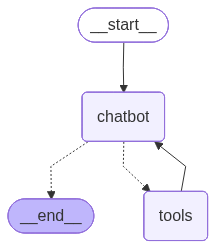

In [69]:
from IPython.display import Image, display

display(Image(tool_agent.get_graph().draw_mermaid_png()))

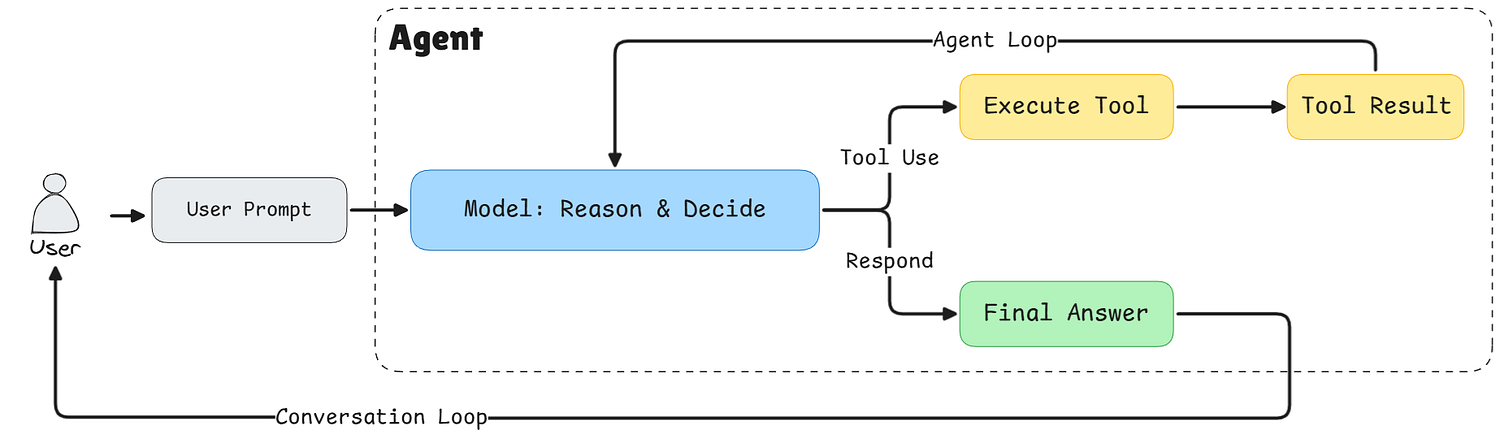

In [ ]:
result = tool_agent.invoke({"messages": [HumanMessage("현재 시점 기준으로 버팀목 대출의 소득 기준을 알려줘. 해당 내용은 .md 파일로 저장해.")]})

과거 메시지 리스트를 예쁘게 출력해봅시다.

In [71]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

현재 시점 기준으로 버팀목 대출의 소득 기준을 알려줘. 해당 내용은 .md 파일로 저장해.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_JttJL1uVLYY0Xg2cTUgFgQPL)
 Call ID: call_JttJL1uVLYY0Xg2cTUgFgQPL
  Args:
    query: 버팀목 전세자금대출 소득 기준 2026 버팀목대출 소득기준 전세자금 버팀목 대출 소득 기준 2025 2026 정부 사이트
    search_depth: advanced
    topic: general
    include_images: False
================================= Tool Message =================================
Name: tavily_search

{"query": "버팀목 전세자금대출 소득 기준 2026 버팀목대출 소득기준 전세자금 버팀목 대출 소득 기준 2025 2026 정부 사이트", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://gobang.kr/contents/6644", "title": "💰최대 2억원 대출 지원! 2026 버팀목전세대출 조건 총정리 (상시모집)", "content": "## \n\n## 🧾 누가 신청할 수 있죠? 자격조건 완벽 정리!\n\n조건이 맞지 않으면 대출이 불가능하니, 자격조건 먼저 체크해보는 게 중요해요!\n\n✅ 신청 조건 총정리\n\n 계약 조건: 전세계약 체결 후 보증금 5% 이상 납부한 상태\n 연령: 만 19세 이상 ~ 34세 이하\n 세

#### User, Agent, Tool 사이의 메시지 전달

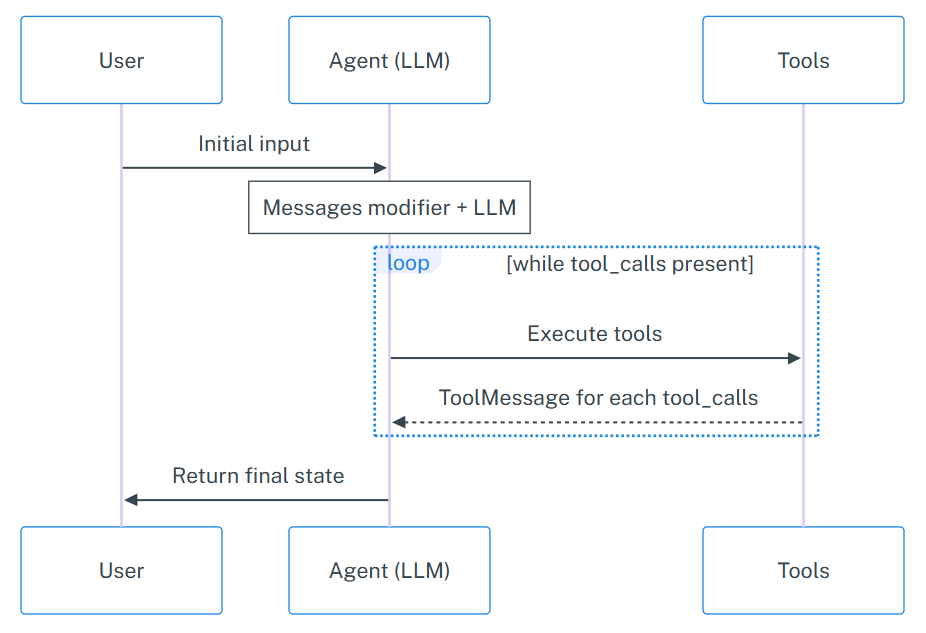

In [72]:
from langgraph.checkpoint.memory import MemorySaver

config = {"configurable": {"thread_id": "conversation_1"}}
memory_tool_agent = agent_builder.compile(checkpointer=MemorySaver())

In [73]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import gradio as gr

# LangGraph 실행 설정 (thread_id로 대화 관리)
config = {"configurable": {"thread_id": "user_123"}}

def user_func(user_message, history: list):
    return "", history + [{"role": "user", "content": user_message}]

def bot_func(history: list):
    result = memory_tool_agent.invoke({"messages": [HumanMessage(history[-1]["content"])]}, config=config)

    try:
        assistant_text = result["messages"][-1].content
    except Exception:
        assistant_text = str(result)

    history.append({"role": "assistant", "content": assistant_text})
    return history

with gr.Blocks(title="Custom Chatbot (gr.Chatbot)") as demo:
    gr.Markdown("### LangGraph 커스텀 챗봇")

    chatbot = gr.Chatbot(
        label="AI Agent",
        height=500,
        type="messages",  # (선택) 새 메시지 포맷과 호환
        show_copy_button=True
    )
    user_input = gr.Textbox(
        placeholder="메시지를 입력하세요...",
        label="입력",
        autofocus=True
    )
    clear_btn = gr.ClearButton([chatbot, user_input])

    # 제출 흐름: (1) 사용자 메시지 추가 -> (2) 봇 응답 생성
    submit_event = user_input.submit(
        user_func,
        inputs=[user_input, chatbot],
        outputs=[user_input, chatbot],
        queue=False
    ).then(
        bot_func,      # LangGraph 호출 후 마지막 턴의 봇 응답 채우기
        inputs=[chatbot],
        outputs=[chatbot]
    )

    # 버튼 클릭으로도 동일 동작 지원
    send_btn = gr.Button("전송")
    send_btn.click(
        user_func,
        inputs=[user_input, chatbot],
        outputs=[user_input, chatbot],
        queue=False
    ).then(
        bot_func,
        inputs=[chatbot],
        outputs=[chatbot]
    )

if __name__ == "__main__":
    demo.launch()

/tmp/ipykernel_6607/206017660.py:25: DeprecationWarning: The 'show_copy_button' parameter will be removed in Gradio 6.0. You will need to use 'buttons=["copy"]' instead.
  chatbot = gr.Chatbot(
/tmp/ipykernel_6607/206017660.py:25: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8bc1e9e63a08b7e232.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
